# Experiment 1

Idea: With a given probability randomly allocate price within the range otherwise give
best action as suggested by policy

In [9]:
import gymnasium as gym
import pandas as pd
import numpy as np
from stable_baselines3.ppo import PPO
import seaborn as sns
import matplotlib.pyplot as plt
import copy

from fair_dynamic_pricing_with_rl.utils.env import FMCGEnv
from fair_dynamic_pricing_with_rl.utils.aids import AIDSEstimator

In [2]:
unit_sales = pd.read_csv("../data/sales_train_evaluation.csv")
prices = pd.read_csv("../data/sell_prices.csv")
calendar = pd.read_csv("../data/calendar.csv")

In [3]:
aids_estimator = AIDSEstimator(
    unit_sales_df = unit_sales,
    prices_df = prices,
    calendar_df = calendar,
    price_granularity = 0.001,
    verbose = False
)

aids_parameters = aids_estimator.run_pipeline()

c:\Users\Kim Levente\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [4]:
# Register the environment so we can create it with gym.make()
gym.register(
    id="gymnasium_env/FMCGEnv",
    entry_point=FMCGEnv,
    max_episode_steps=500,  # Prevent infinite episodes
)

In [5]:
env = gym.make("gymnasium_env/FMCGEnv",
               p_min=aids_parameters[0],
               p_max=aids_parameters[1],
               p_diff=aids_parameters[2],
               alpha=aids_parameters[3],
               gamma=aids_parameters[4],
               beta=aids_parameters[5],
               budget=aids_parameters[6],
               real_budget=aids_parameters[7],
               noise_range=1
               )

In [10]:
# PPO hyperparameters from Liu et al. (2024)
model = PPO(policy="MultiInputPolicy",
            env=env,
            learning_rate=0.0001,
            batch_size=64, # default
            clip_range=0.2, # default
            )
model.learn(total_timesteps=25000)

In [13]:
def running_model(env1,
                  alg,
                  H,
                  T,
                  num_products,
                  random_action_prob=0.5,
                  seed=None
                  ):
    """ Policy choosing for T episodes of length H.
    """

    env = copy.deepcopy(env1)

    # dedicated RNG for random action override plus seeding action sampler
    rng = np.random.default_rng(seed)
    env.action_space.seed(seed)

    rew = np.zeros((H,T))
    action_hist = np.zeros((H,T,num_products))
    groups = np.zeros((H,T))
    # reg = np.zeros(T)

    for t in range(T):
        # sample initial state
        # seed each reset deterministically but distinctly per episode
        observation, info = env.reset(seed=None if seed is None else seed + t)
        # optval =
        
        #record reward received over episode
        eprew = 0.0
        for h in range(H):
            # save the group wrt. sensitive attribute
            groups[h,t] = observation['sensitive_attr']
            
            # take action using trained model
            action, _states = alg.predict(observation, deterministic=True)
            a = np.asarray(action)
            
            # with random_action_prob override with a random action
            if rng.random() < random_action_prob:
                a = env.action_space.sample()
                a = np.asarray(a)
            
            action_hist[h,t] = a

            # record new state/reward from action played
            observation, reward, terminated, truncated, info = env.step(a)
            eprew += reward

            # reg[t] = optval -eprew 
            rew[h,t] = reward
        
    return rew, action_hist, groups

In [15]:
rewards, action_hist, groups = running_model(env, model, 52, 1000, 3,
                                            0.5, 42)

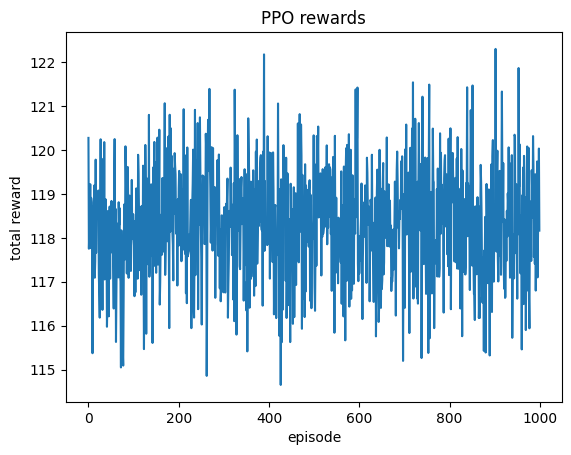

In [16]:
sns.lineplot(rewards.mean(axis=0))
plt.xlabel("episode")
plt.ylabel("total reward")
plt.title("PPO rewards")
plt.show()

In [17]:
def compute_jains_index(env, action_hist, groups, rew, metric="revenue"):
    """
    Compute Jain's fairness index across sensitive-attribute (SNAP-proxied) groups.

    Args:
        env: FMCGEnv instance — only used for its `_action_to_price` method
        action_hist: array (H, T, L) of raw action indices taken by the policy
        groups: array (H, T) of sensitive attribute labels (0/1)
        rew: array (H, T) of realized rewards (already p @ demand)
        metric: "revenue" -> use realized reward directly per group
                "price"   -> recompute prices from actions and aggregate
                             mean total basket price per group

    Returns:
        jains_index: float
        group_values: dict {group_label: aggregated_value}
    """
    unique_groups = np.unique(groups)
    group_values = {}

    if metric == "revenue":
        for g in unique_groups:
            mask = (groups == g)
            group_values[g] = rew[mask].mean()

    elif metric == "price":
        H, T, L = action_hist.shape
        prices = np.zeros((H, T, L))
        for t in range(T):
            for h in range(H):
                prices[h, t, :] = env._action_to_price(action_hist[h, t, :])

        total_price = prices.sum(axis=2)  # basket price per (h, t)

        for g in unique_groups:
            mask = (groups == g)
            group_values[g] = total_price[mask].mean()

    else:
        raise ValueError("metric must be 'revenue' or 'price'")

    x = np.array(list(group_values.values()))
    n = len(x)
    jains_index = (x.sum() ** 2) / (n * np.sum(x ** 2))

    return jains_index, group_values

In [19]:
j_revenue, gv_rev = compute_jains_index(env, action_hist, groups, rewards, metric="revenue")
j_price,   gv_pr  = compute_jains_index(env, action_hist, groups, rewards, metric="price")

print(f"Jain's index (revenue-based): {j_revenue:.4f}")
print(f"Jain's index (price-based):   {j_price:.4f}")

AttributeError: 'TimeLimit' object has no attribute '_action_to_price'